In [7]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

project_root = Path("/home/akapociu/ift/interactiondynamics")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from data.one_dimension_wave_binned import WaveEquationBinnedConfig, WaveEquationBinnedDataset


In [16]:
cfg = WaveEquationBinnedConfig(
    num_nodes= 64,
    num_bins= 400,
    event_mode="thresholded",
    interaction_threshold=0.0,
    threshold_metric="pair_accel",
    threshold_use_absolute=True,
    threshold_keep_one_if_empty=True,
)

ds = WaveEquationBinnedDataset(cfg)
spec = ds.spec()
spec

DataSpec(name='wave_equation_binned', num_nodes=64, event_dim=14, num_events=51200, num_bins=400, extra={'physics': '1D periodic wave equation in first-order form', 'interaction_view': 'pairwise nearest-neighbor spring-like coupling on a ring', 'state_layout': '[q_0..q_{N-1}, v_0..v_{N-1}]', 'split_fracs': (0.7, 0.15, 0.15), 't_span': (0.0, 20.0), 'dt': 0.05012531328320802, 'dx': 0.015625, 'domain_length': 1.0, 'wave_speed': 1.0, 'damping': 0.0, 'feature_names': ['recv_x', 'send_x', 'recv_q', 'recv_v', 'send_q', 'send_v', 'rel_q', 'rel_v', 'direction', 'dx', 'pair_grad', 'pair_accel_contrib', 'recv_local_energy', 'global_energy'], 'event_mode': 'thresholded', 'interaction_threshold': 0.0, 'threshold_metric': 'pair_accel', 'threshold_use_absolute': True, 'threshold_keep_one_if_empty': True, 'observation_noise_q': 0.0, 'observation_noise_v': 0.0})

In [17]:
batch0 = next(iter(ds.bins("train")))
print(batch0.src[:10])
print(batch0.dst[:10])
print(batch0.features.shape if batch0.features is not None else None)
print(spec.extra)

tensor([63,  1,  0,  2,  1,  3,  2,  4,  3,  5])
tensor([0, 0, 1, 1, 2, 2, 3, 3, 4, 4])
torch.Size([128, 14])
{'physics': '1D periodic wave equation in first-order form', 'interaction_view': 'pairwise nearest-neighbor spring-like coupling on a ring', 'state_layout': '[q_0..q_{N-1}, v_0..v_{N-1}]', 'split_fracs': (0.7, 0.15, 0.15), 't_span': (0.0, 20.0), 'dt': 0.05012531328320802, 'dx': 0.015625, 'domain_length': 1.0, 'wave_speed': 1.0, 'damping': 0.0, 'feature_names': ['recv_x', 'send_x', 'recv_q', 'recv_v', 'send_q', 'send_v', 'rel_q', 'rel_v', 'direction', 'dx', 'pair_grad', 'pair_accel_contrib', 'recv_local_energy', 'global_energy'], 'event_mode': 'thresholded', 'interaction_threshold': 0.0, 'threshold_metric': 'pair_accel', 'threshold_use_absolute': True, 'threshold_keep_one_if_empty': True, 'observation_noise_q': 0.0, 'observation_noise_v': 0.0}


THRESHOLD OPTIONS:

rel_q = q_j - q_i
- Displacement mismatch between neighboring nodes (grid sites)
- If neighbors are at similar displacement, edge looks weak and vice versa
- Simplest option

rel_v = v_j - v_i
- Velocity mismatch between neighbors
- Keep edges where nearby nodes are moving differently (more dynamic contrast rather than shape contrast)
- Less directly tied to spatial wave coupling term

pair_grad = (q_j - q_i)/dx
- Local spatial slope between neighbors
- Big if the wave is steep there, small if field is flat
- Good physical interpretatation for waves

pair_accel_contrib = c^2 (q_j - q_i)/dx^2
- Pairwise contribution to the receiver's acceleration from that neighbor
- Most directly tied to actual discrete wave equation
- How much is this node trying pull/push this site?
- Therefore, more physics faithful option (also very similar to spring-mass problem)


- For every candidate neighbor edge in every val bin, we look at the chosen edge feature values (with 300 bins and 64 edges per bin -> 19,3000 total candidate edges checked)
- Across all 19,200 possible neighbor interactions, how big is this quantity usually?

For example: 
=== pair_grad ===
count: 19200
min:   0.000665364
mean:  5.9719
std:   4.48648
max:   28.3768
p50:   5.09786
p75:   8.61607
p90:   12.1937
p95:   14.5258
p99:   19.0841

- 50% of the edge values are below 5.10 and half above it (p50)
- 75% are below 8.62, so the top 25% values are above that
- So if you set interaction_threshold = 8.61607, you are keeping only edges in the strongest top 25% by absolute local slope (value >= 8.61607)
- Pick percentile based on how sparse or dense you want each bin to be

feature_names: ['recv_x', 'send_x', 'recv_q', 'recv_v', 'send_q', 'send_v', 'rel_q', 'rel_v', 'direction', 'dx', 'pair_grad', 'pair_accel_contrib', 'recv_local_energy', 'global_energy']
metric_idx: {'pair_accel_contrib': 11, 'rel_q': 6, 'rel_v': 7, 'pair_grad': 10}
num bins inspected: 60
edges per bin (first few): [128, 128, 128, 128, 128, 128, 128, 128, 128, 128]
mean edges/bin: 128.00

=== pair_accel_contrib ===
count: 7680
min:   0.211678
mean:  454.292
std:   336.263
max:   1735.55
p50:   391.396
p75:   658.964
p90:   941.704
p95:   1107.05
p99:   1382.57

=== rel_q ===
count: 7680
min:   5.16791e-05
mean:  0.110911
std:   0.0820955
max:   0.423718
p50:   0.0955556
p75:   0.16088
p90:   0.229908
p95:   0.270277
p99:   0.337543

=== rel_v ===
count: 7680
min:   0.00215291
mean:  7.0312
std:   5.2822
max:   29.0968
p50:   6.08198
p75:   10.2944
p90:   14.1808
p95:   17.2937
p99:   22.5467

=== pair_grad ===
count: 7680
min:   0.00330746
mean:  7.09831
std:   5.25411
max:   27.118
p50

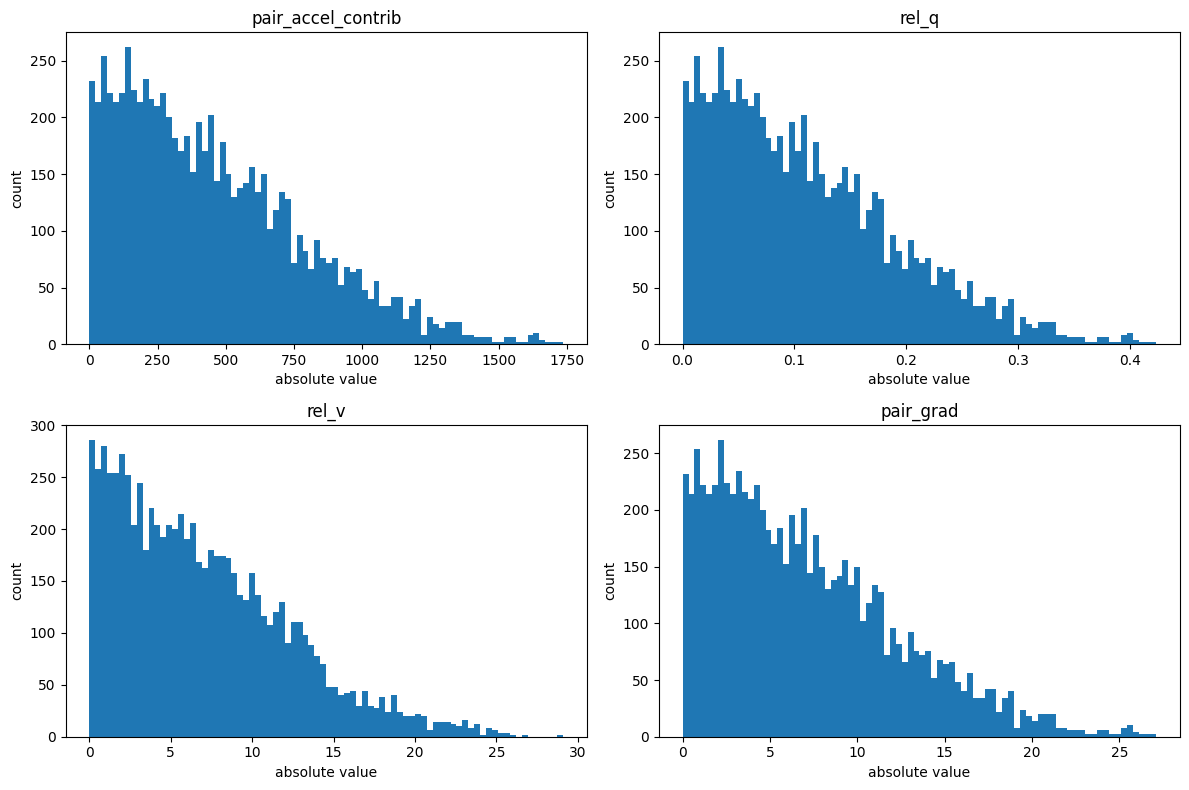


=== Estimated sparsity by percentile cutoff ===

--- pair_accel_contrib ---
p50 threshold = 391.396 | mean kept/bin = 64.00 | min = 50 | max = 80
p75 threshold = 658.964 | mean kept/bin = 32.00 | min = 12 | max = 46
p90 threshold = 941.704 | mean kept/bin = 12.80 | min = 2 | max = 28
p95 threshold = 1107.05 | mean kept/bin = 6.40 | min = 0 | max = 16
p99 threshold = 1382.57 | mean kept/bin = 1.30 | min = 0 | max = 6

--- rel_q ---
p50 threshold = 0.0955556 | mean kept/bin = 64.00 | min = 50 | max = 80
p75 threshold = 0.16088 | mean kept/bin = 32.00 | min = 12 | max = 46
p90 threshold = 0.229908 | mean kept/bin = 12.80 | min = 2 | max = 28
p95 threshold = 0.270277 | mean kept/bin = 6.40 | min = 0 | max = 16
p99 threshold = 0.337543 | mean kept/bin = 1.30 | min = 0 | max = 6

--- rel_v ---
p50 threshold = 6.08198 | mean kept/bin = 64.00 | min = 46 | max = 82
p75 threshold = 10.2944 | mean kept/bin = 32.00 | min = 14 | max = 52
p90 threshold = 14.1808 | mean kept/bin = 12.80 | min = 2 | 

In [18]:
# -----------------------------
# config
# -----------------------------
split = "test"          # or "val" / "test"
use_abs = True           # matches threshold_use_absolute=True
percentiles = [50, 75, 90, 95, 99]

# -----------------------------
# figure out feature names
# -----------------------------
feature_names = spec.extra.get("feature_names", None)
if feature_names is None:
    raise ValueError("spec.extra['feature_names'] not found")

feature_names = list(feature_names)
print("feature_names:", feature_names)

wanted_metrics = ["pair_accel_contrib", "rel_q", "rel_v", "pair_grad"]

missing = [m for m in wanted_metrics if m not in feature_names]
if missing:
    raise ValueError(f"Missing expected metrics in feature_names: {missing}")

metric_idx = {m: feature_names.index(m) for m in wanted_metrics}
print("metric_idx:", metric_idx)

# -----------------------------
# collect per-bin values
# -----------------------------
metric_values = {m: [] for m in wanted_metrics}
metric_values_by_bin = {m: [] for m in wanted_metrics}
edges_per_bin = []

for batch in ds.bins(split):
    if batch.features is None:
        continue

    feats = batch.features.detach().cpu().numpy()   # [num_edges, num_features]
    edges_per_bin.append(feats.shape[0])

    for m in wanted_metrics:
        vals = feats[:, metric_idx[m]]
        if use_abs:
            vals = np.abs(vals)

        metric_values[m].append(vals)
        metric_values_by_bin[m].append(vals)

print(f"num bins inspected: {len(edges_per_bin)}")
print(f"edges per bin (first few): {edges_per_bin[:10]}")
print(f"mean edges/bin: {np.mean(edges_per_bin):.2f}")

# concatenate all bins
for m in wanted_metrics:
    metric_values[m] = np.concatenate(metric_values[m]) if metric_values[m] else np.array([])

# -----------------------------
# summary stats
# -----------------------------
for m in wanted_metrics:
    vals = metric_values[m]
    print(f"\n=== {m} ===")
    print(f"count: {len(vals)}")
    print(f"min:   {vals.min():.6g}")
    print(f"mean:  {vals.mean():.6g}")
    print(f"std:   {vals.std():.6g}")
    print(f"max:   {vals.max():.6g}")
    for p in percentiles:
        print(f"p{p}:   {np.percentile(vals, p):.6g}")

# -----------------------------
# histograms
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, m in zip(axes, wanted_metrics):
    vals = metric_values[m]
    ax.hist(vals, bins=80)
    ax.set_title(m)
    ax.set_xlabel("absolute value" if use_abs else "value")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

# -----------------------------
# survival counts by percentile threshold
# -----------------------------
print("\n=== Estimated sparsity by percentile cutoff ===")
for m in wanted_metrics:
    print(f"\n--- {m} ---")
    all_vals = metric_values[m]

    for p in percentiles:
        thr = np.percentile(all_vals, p)

        kept_counts = []
        for vals_bin in metric_values_by_bin[m]:
            kept = (vals_bin >= thr).sum()
            kept_counts.append(int(kept))

        kept_counts = np.array(kept_counts)

        print(
            f"p{p:>2} threshold = {thr:.6g} | "
            f"mean kept/bin = {kept_counts.mean():.2f} | "
            f"min = {kept_counts.min()} | "
            f"max = {kept_counts.max()}"
        )

In [11]:
from collections import Counter
split = "val"

edge_counts = []   
for batch in ds.bins(split):
    n_edges = int(batch.src.numel())
    edge_counts.append(n_edges)

edge_counts = np.array(edge_counts)

print(f"=== Edge count stats for split={split!r} ===")
print(f"num_bins:         {len(edge_counts)}")
print(f"total_edges:      {edge_counts.sum()}")
print(f"min_edges/bin:    {edge_counts.min()}")
print(f"max_edges/bin:    {edge_counts.max()}")
print(f"mean_edges/bin:   {edge_counts.mean():.2f}")
print(f"median_edges/bin: {np.median(edge_counts):.2f}")
print(f"std_edges/bin:    {edge_counts.std():.2f}")
print(f"first 10 bins:    {edge_counts[:10].tolist()}")

count_freq = Counter(edge_counts.tolist())

print("\n=== Bin count frequency ===")
for edge_count in sorted(count_freq):
    print(f"{count_freq[edge_count]} bins have {edge_count} edges")

=== Edge count stats for split='val' ===
num_bins:         300
total_edges:      19200
min_edges/bin:    64
max_edges/bin:    64
mean_edges/bin:   64.00
median_edges/bin: 64.00
std_edges/bin:    0.00
first 10 bins:    [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]

=== Bin count frequency ===
300 bins have 64 edges
